In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
print(os.getcwd())

sys.path.append("..")
from src.features import compute_chromagram
from src.visualization import plot_chromagram, plot_chord_similarity
from src.templates import generate_chord_templates, get_chord_labels, VOCAB_CLASSICAL
from src.recognition import recognize_template

/Users/hannaharjonillo/Documents/Projects/fmp-chord-recognition/notebooks


In [2]:
audio_path = "../data/audio/chopin_etude_op25_no01.mp3"
dict_chroma = {
    "STFT": compute_chromagram(
        audio_path=audio_path,
        variant="STFT"
    ),
    "IIR": compute_chromagram(
        audio_path=audio_path,
        variant="IIR"
    ),
    "CQT": compute_chromagram(
        audio_path=audio_path,
        variant="CQT"
    )
}

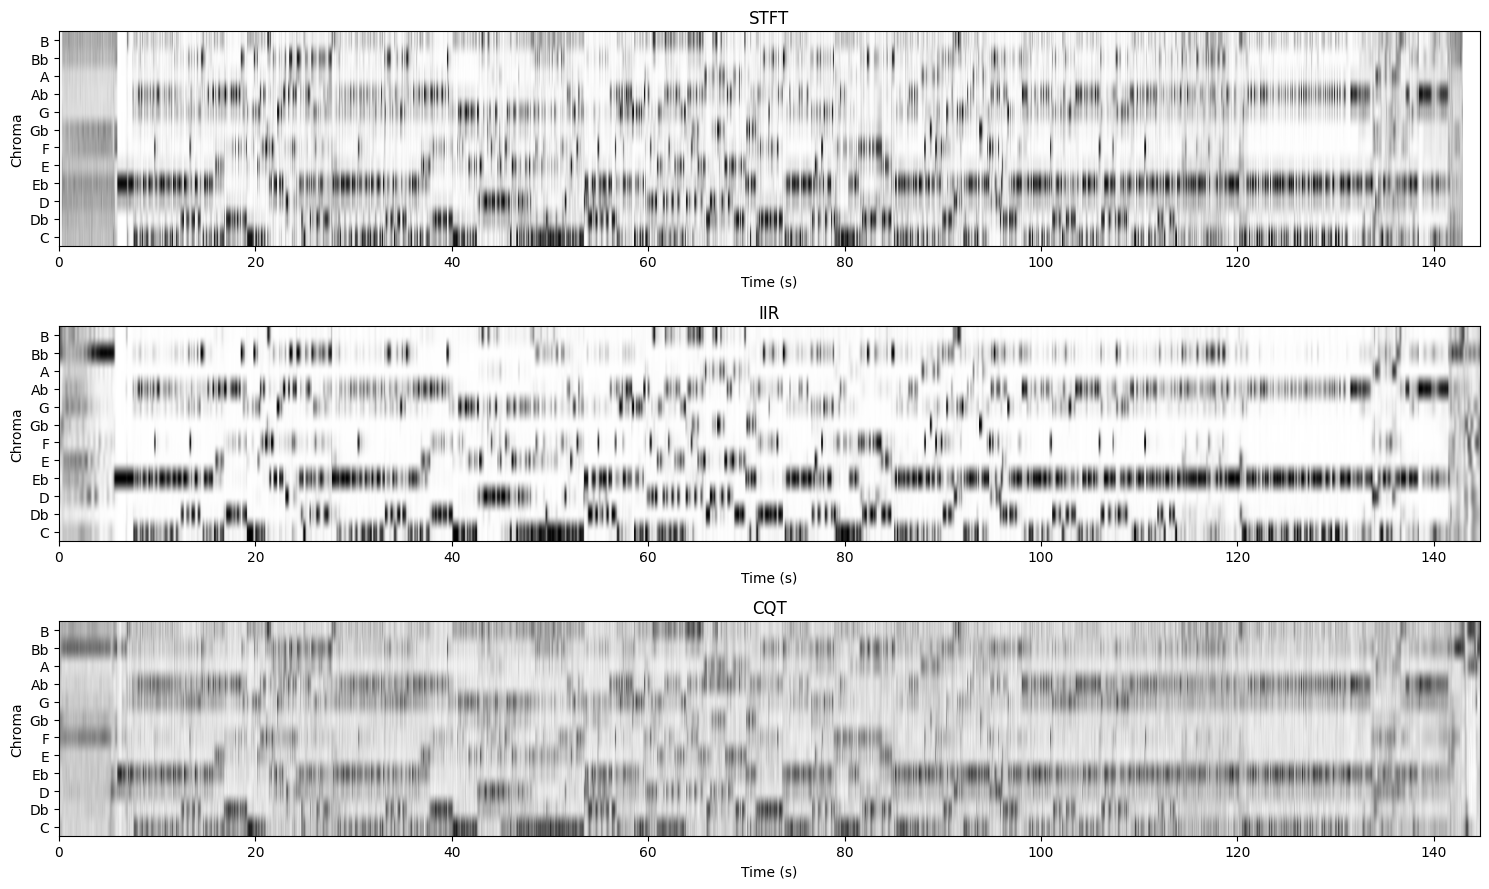

In [3]:
fig, axs = plt.subplots(3, 1, figsize=(15, 9))
for i, (variant, chroma_v) in enumerate(dict_chroma.items()):
    plot_chromagram(
        X=chroma_v.X,
        feature_rate=chroma_v.feature_rate,
        ax=axs[i],
        use_flats=True
    )
    axs[i].set_title(variant)
plt.tight_layout()

In [4]:
result_recognition = recognize_template(
    chroma=dict_chroma["IIR"]
)

In [7]:
result_recognition.chord_sim.shape

(24, 1558)

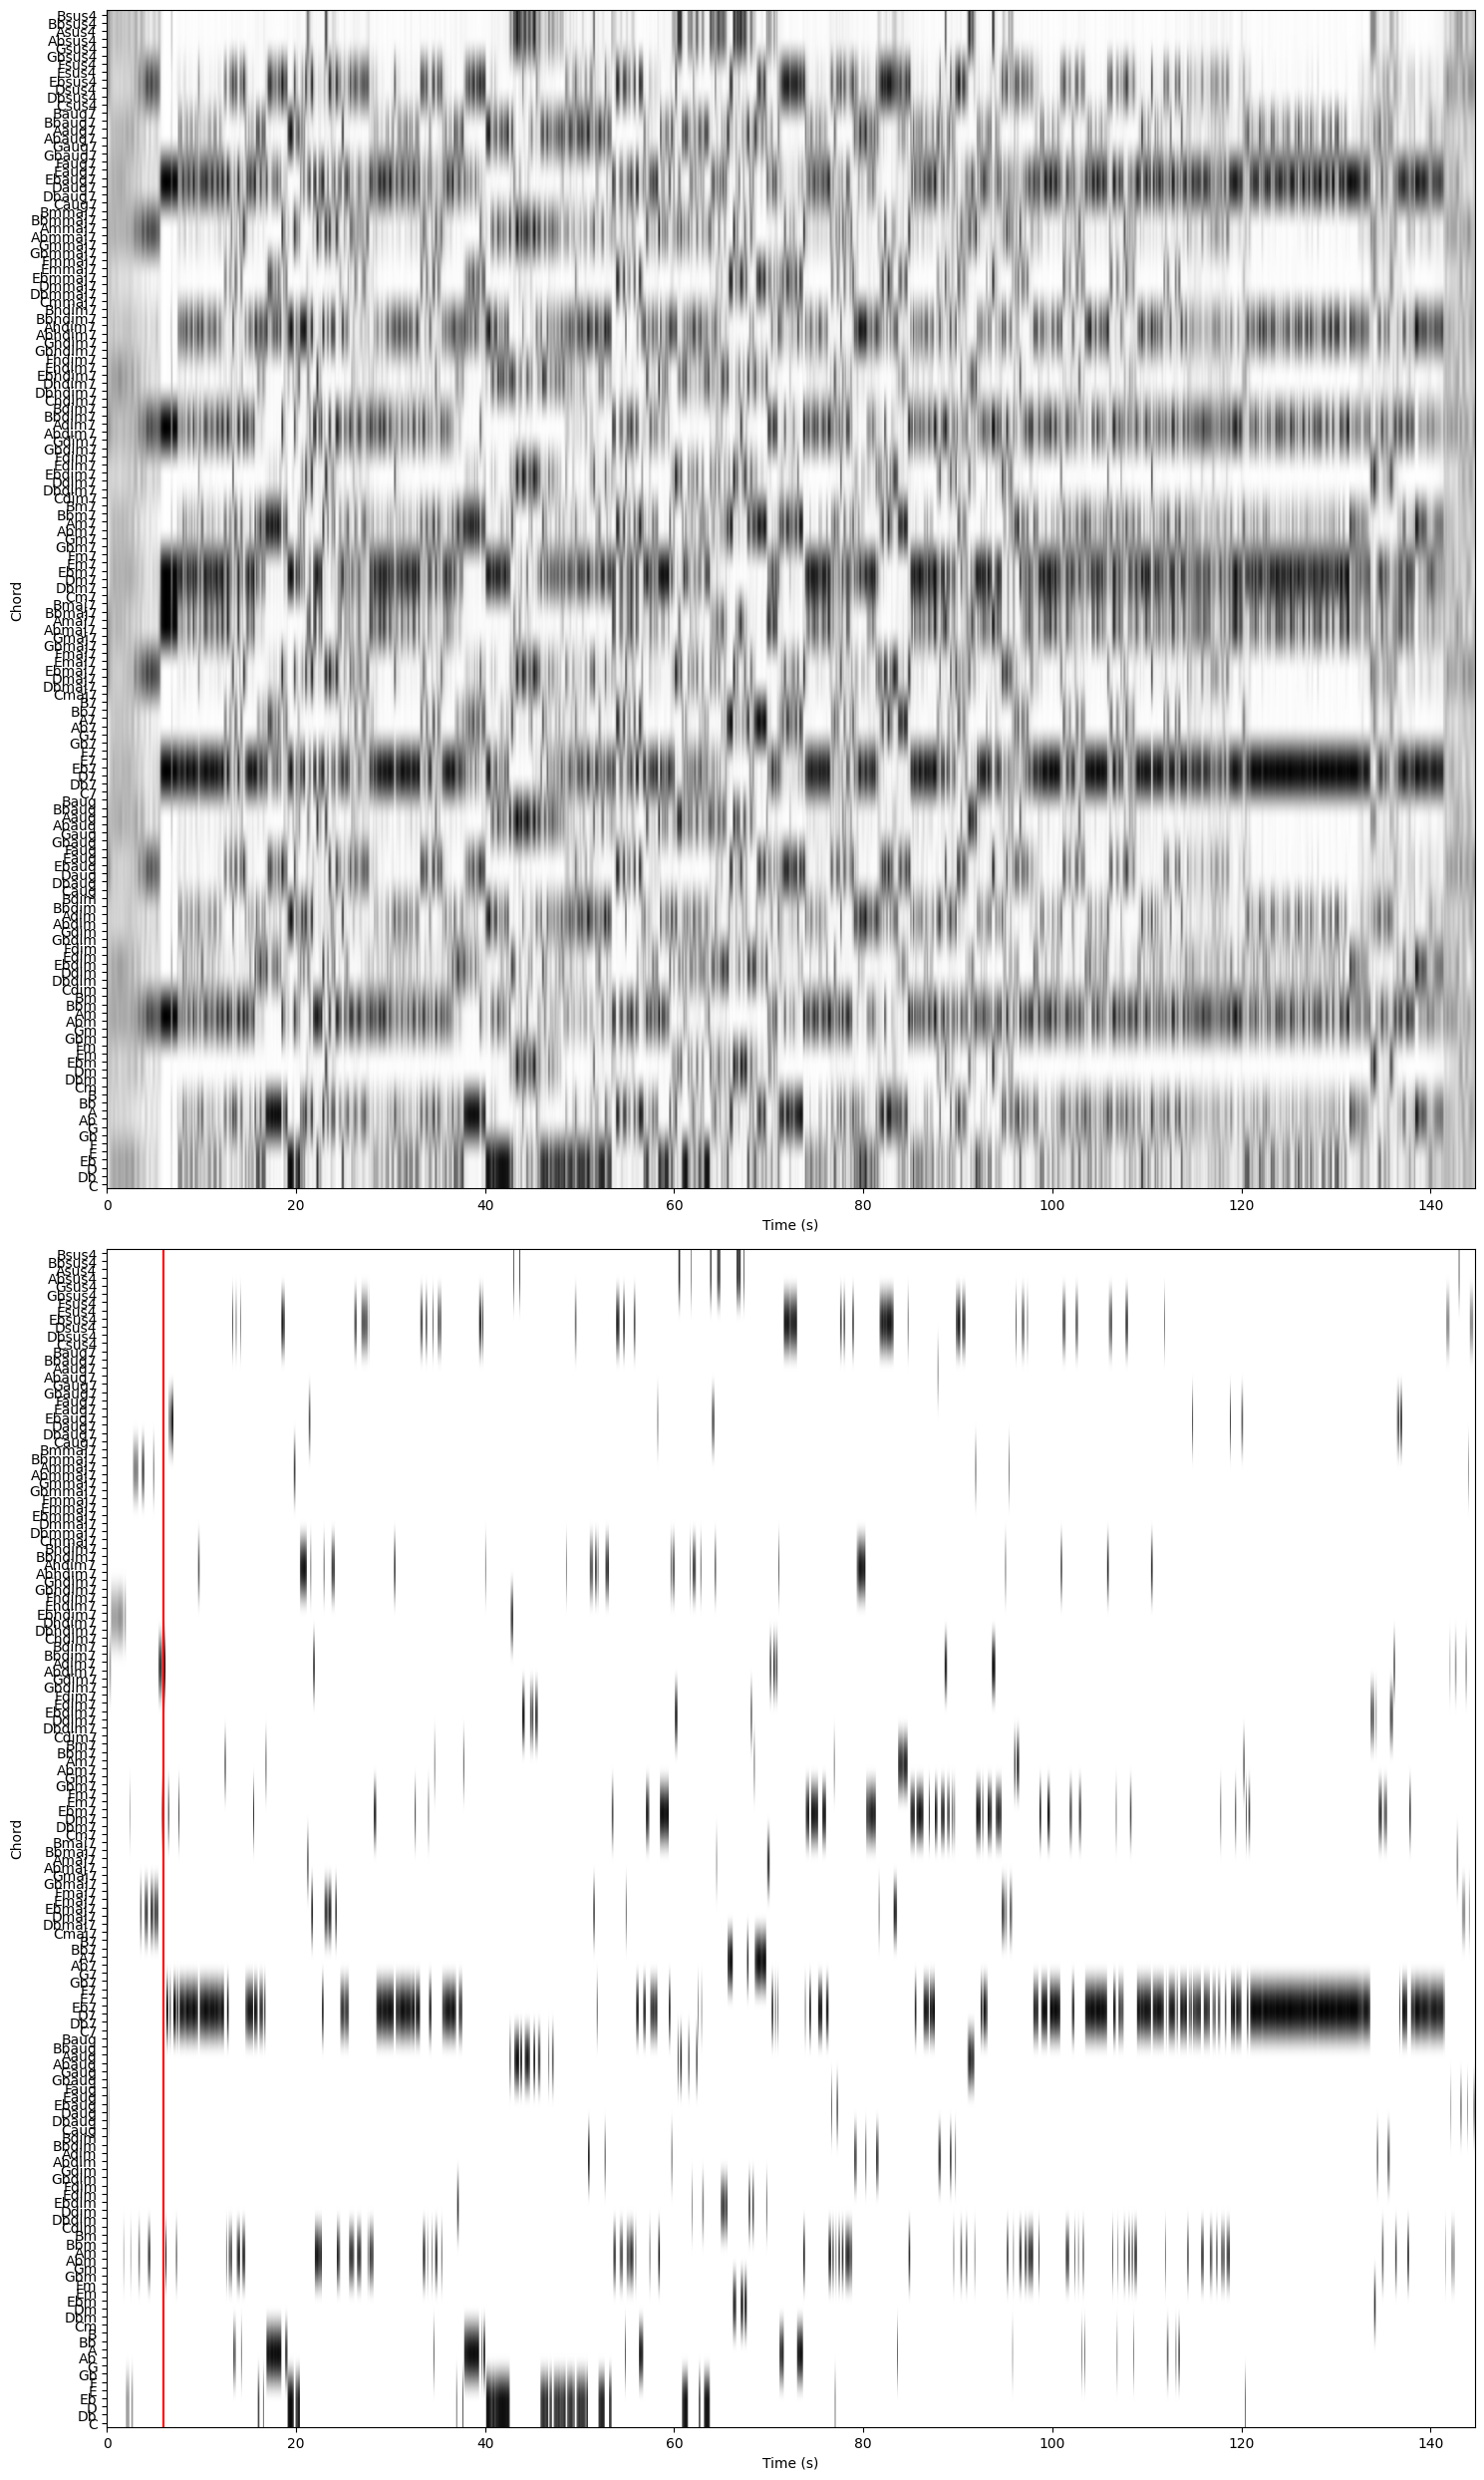

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(15,25))
plot_chord_similarity(
    ax=axs[0],
    chord_sim=result_recognition.chord_sim,
    feature_rate=dict_chroma["IIR"].feature_rate,
    use_flats=True,
)
plot_chord_similarity(
    ax=axs[1],
    chord_sim=result_recognition.chord_max,
    feature_rate=dict_chroma["IIR"].feature_rate,
    use_flats=True
)
axs[1].axvline(x=6, color="red")
fig.tight_layout()